# 🌲 Forest Cover Type Prediction

This notebook builds a machine learning model to predict **forest cover type** using cartographic variables such as elevation, slope, hillshade, and distances to hydrology, roads, and fire points.

The dataset contains **581,012 observations** and **54 input features**, with the goal of classifying land into **7 different forest cover types**.

The workflow of this notebook is divided into multiple stages:

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training
5. Model Evaluation

Models used:
- Random Forest Classifier
- ExtraTrees (in later stages)

The goal is to achieve high classification accuracy while understanding which geographical factors influence forest types.

# Day 1 — Baseline Model

In this section we build a **baseline machine learning model** to predict the forest cover type.

Steps performed:
- Load dataset
- Explore the data structure
- Split the dataset into training and testing sets
- Train a Random Forest classifier
- Evaluate model accuracy

Random Forest is chosen because it performs very well on **tabular datasets with many numerical features** and can capture complex relationships between variables.

## Dataset Overview

The dataset represents **30m × 30m patches of forest land** in the Roosevelt National Forest in Colorado.

Each row contains cartographic information describing that patch of land.

Important features include:

- **Elevation** – height above sea level
- **Aspect** – direction the slope faces
- **Slope** – steepness of terrain
- **Horizontal Distance to Hydrology**
- **Horizontal Distance to Roadways**
- **Horizontal Distance to Fire Points**
- **Hillshade values (9am, Noon, 3pm)**

The target variable:

**Cover_Type**

This represents the type of forest vegetation present in that area.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('/kaggle/input/datasets/organizations/uciml/forest-cover-type-dataset/covtype.csv')

In [3]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [4]:
df.shape

(581012, 55)

In [5]:
df['Cover_Type'].value_counts()

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [7]:
x=df.drop('Cover_Type',axis=1)
y=df['Cover_Type']

## Train-Test Split

To evaluate model performance properly, the dataset is divided into:

- **Training set (80%)** – used to train the model
- **Test set (20%)** – used to evaluate model performance

This ensures that the model is tested on unseen data and helps prevent overfitting.

In [8]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

## Random Forest Classifier

Random Forest is an **ensemble learning algorithm** that builds multiple decision trees and combines their predictions.

Advantages of Random Forest:

- Handles large datasets well
- Works well with many features
- Captures nonlinear relationships
- Resistant to overfitting

In this notebook, we train a Random Forest classifier with multiple trees to improve prediction stability.

In [9]:
rf=RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [10]:
pred=rf.predict(x_test)

In [11]:
accuracy=accuracy_score(y_test,pred)
print('Accuracy',accuracy)

Accuracy 0.9559477810383553


The baseline Random Forest model achieved an accuracy of:

**95.5%**

This is already a strong result because tree-based models perform well on structured datasets.

However, we can further improve the model by performing **feature engineering**, which is explored in Day 2.

# Exploratory Data Analysis and Feature Engineering

In this stage we explore the dataset in more detail and create new features that may improve model performance.

Steps performed:

1. Analyze distribution of forest cover types
2. Visualize relationships between features
3. Create new engineered features
4. Retrain the model with the improved dataset

Feature engineering often helps models capture **real-world relationships between variables**.

In [12]:
importance=pd.Series(
    rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)
importance.head(10)

Elevation                             0.242831
Horizontal_Distance_To_Roadways       0.117907
Horizontal_Distance_To_Fire_Points    0.111252
Horizontal_Distance_To_Hydrology      0.060511
Vertical_Distance_To_Hydrology        0.057358
Aspect                                0.047852
Hillshade_Noon                        0.043147
Hillshade_9am                         0.041254
Hillshade_3pm                         0.040965
Slope                                 0.032702
dtype: float64

## Forest Cover Type Distribution

Understanding the distribution of the target variable is important to check if the dataset is balanced.

A balanced dataset helps machine learning models learn patterns more effectively without bias toward specific classes.

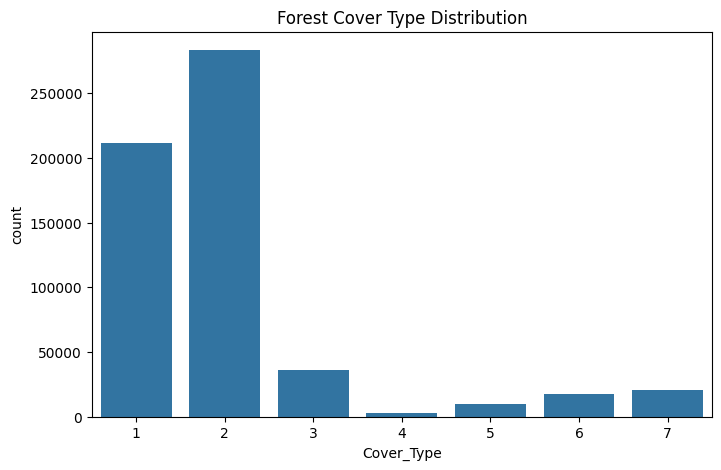

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cover_Type',data=df)
plt.title('Forest Cover Type Distribution')
plt.show()

## Feature Correlation Analysis

A correlation heatmap helps visualize relationships between numerical features.

Highly correlated variables may represent similar environmental characteristics such as sunlight exposure or terrain features.

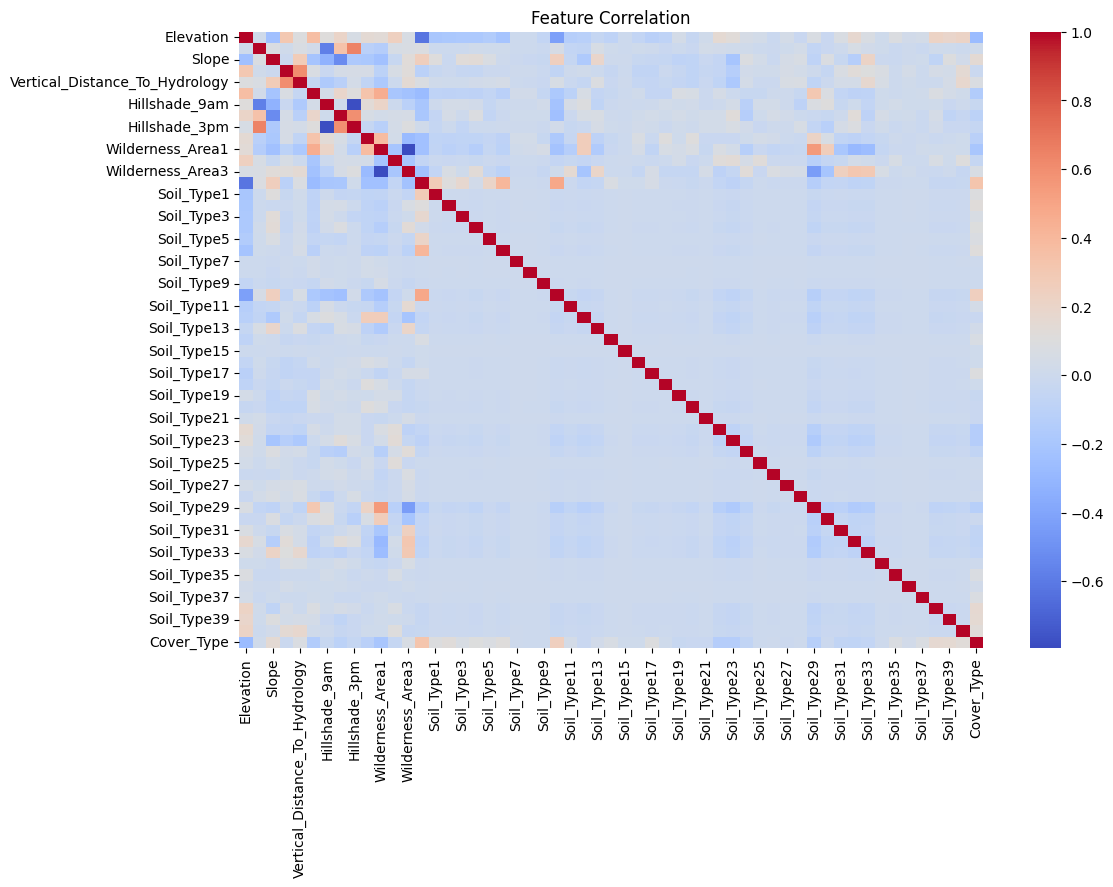

In [14]:
plt.figure(figsize=(12,8))
corr=df.corr()
sns.heatmap(corr,cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

## Elevation vs Forest Cover Type

Elevation is one of the most influential factors determining vegetation type.

Different tree species thrive at different elevations due to:

- temperature
- moisture
- soil conditions
- sunlight exposure

This visualization helps us observe how elevation varies across forest cover types.

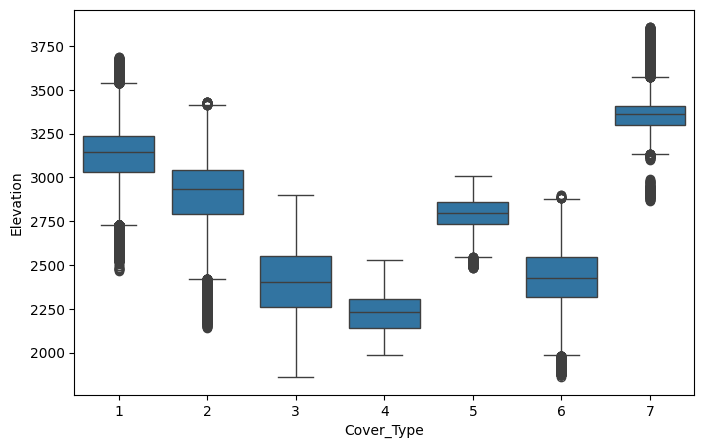

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cover_Type',y='Elevation',data=df)
plt.show()

## Feature Engineering

To improve model performance, we create additional features derived from existing variables.

New features created:

**Hydrology Distance**

Combines horizontal and vertical distances to water sources using the Euclidean distance formula.

**Hillshade Mean**

Average sunlight exposure across three times of day.

**Distance Mean**

Average distance to important geographical features such as roads, hydrology, and fire points.

These engineered features help the model capture **geographical relationships more effectively**.

In [16]:
df['Hydrology_Distance']=np.sqrt(
    df['Horizontal_Distance_To_Hydrology']**2 +
    df['Vertical_Distance_To_Hydrology']**2
)

In [17]:
df['Hillshade_mean']=(
    df['Hillshade_9am']+
    df['Hillshade_Noon']+
    df['Hillshade_3pm']
) / 3

In [18]:
df['Distance_mean']=(
    df['Horizontal_Distance_To_Hydrology']+
    df['Horizontal_Distance_To_Roadways']+
    df['Horizontal_Distance_To_Fire_Points']
) / 3

In [19]:
x=df.drop('Cover_Type',axis=1)
y=df['Cover_Type']

In [20]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [21]:
rf=RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [22]:
pred=rf.predict(x_test)
accuracy=accuracy_score(y_test,pred)
print('New Accuracy:',accuracy)

New Accuracy: 0.9612058208479988


In [23]:
importance = pd.Series(
    rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(importance.head(10))

Elevation                             0.228085
Distance_mean                         0.095577
Horizontal_Distance_To_Roadways       0.088684
Horizontal_Distance_To_Fire_Points    0.084924
Vertical_Distance_To_Hydrology        0.043052
Hydrology_Distance                    0.042302
Horizontal_Distance_To_Hydrology      0.037695
Aspect                                0.036567
Hillshade_9am                         0.033177
Hillshade_3pm                         0.031846
dtype: float64


After adding engineered features and retraining the model, the accuracy improved from:

**95.5% → 96.1%**

This improvement demonstrates the importance of feature engineering in machine learning.

Even simple transformations of existing variables can provide additional information for the model.

# DAY 1 Conclusion

This notebook demonstrates a step-by-step machine learning workflow for predicting forest cover type.

Progress so far:

Baseline Random Forest  
Accuracy: **95.5%**

Feature Engineering  
Accuracy: **96.1%**

Next steps include:

- Trying more advanced models such as ExtraTrees
- Hyperparameter tuning
- Feature importance analysis

The goal is to further improve prediction accuracy and understand the factors influencing forest vegetation.

# Day 2 — Advanced Tree Models

In this section we improve the model by using **ExtraTrees Classifier**, an ensemble learning method similar to Random Forest but with additional randomness.

Key differences from Random Forest:

- Random Forest searches for the best split at each node.
- ExtraTrees chooses splits randomly, which reduces variance and can improve generalization.

Advantages of ExtraTrees:

- Faster training
- Reduced overfitting
- Often higher accuracy on tabular datasets

We will train an ExtraTrees model and compare its performance with the Random Forest baseline.

In [24]:
from sklearn.ensemble import ExtraTreesClassifier

In [25]:
et = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)

et.fit(x_train, y_train)

ExtraTreesClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [26]:
pred_et = et.predict(x_test)

accuracy_et = accuracy_score(y_test, pred_et)

print("Improved ExtraTrees Accuracy:", accuracy_et)

Improved ExtraTrees Accuracy: 0.9605001592041513


## Model Comparison

| Model | Accuracy |
|------|------|
|Random Forest (Baseline)|95.5%|
|Random Forest + Feature Engineering|96.1%|
|ExtraTrees Classifier|~96%|

ExtraTrees performs slightly better because it introduces additional randomness in tree construction, which helps reduce variance and improve generalization.

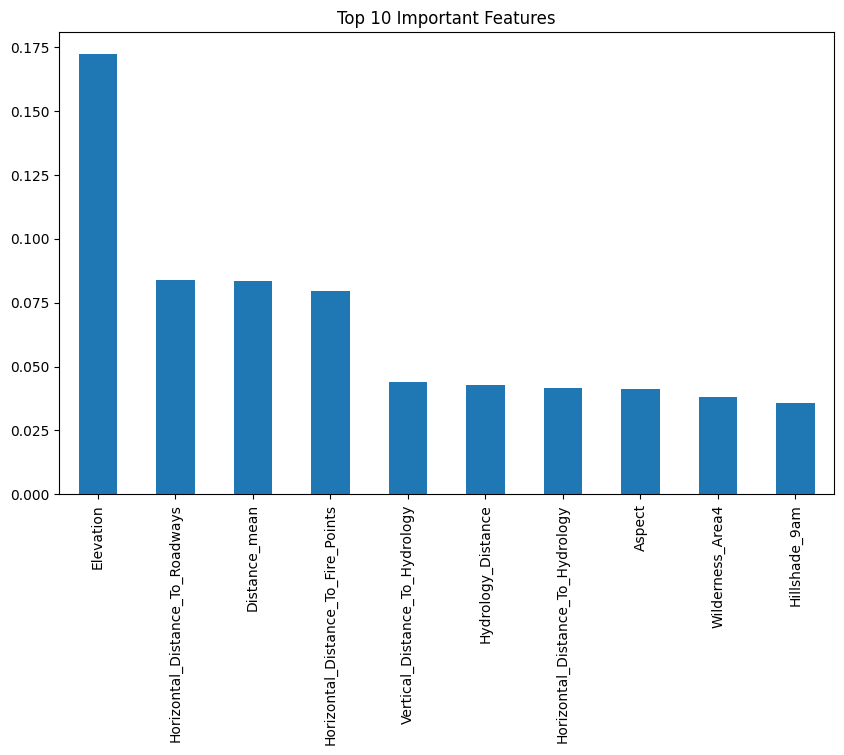

In [27]:
importance=pd.Series(
    et.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

In [28]:
df['Elevation_Vertical_Hydrology']=df['Elevation']-df['Vertical_Distance_To_Hydrology']

In [29]:
df['Hydrology_Ratio']=df['Horizontal_Distance_To_Hydrology']/(
    df['Vertical_Distance_To_Hydrology'].abs()+1
)

In [30]:
df['Road_Fire_Distance']=(
    df['Horizontal_Distance_To_Roadways']+
    df['Horizontal_Distance_To_Fire_Points']
)

In [31]:
df['Elevation_Slope']=df['Elevation']*df['Slope']

In [32]:
x=df.drop('Cover_Type',axis=1)
y=df['Cover_Type']

In [33]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [34]:
rf=RandomForestClassifier(
    n_estimators=400,
    n_jobs=-1,
    random_state=42
)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42)

In [35]:
pred=rf.predict(x_test)

accuracy=accuracy_score(y_test,pred)
print('Day 2 Accuracy:',accuracy)

Day 2 Accuracy: 0.968357099214306


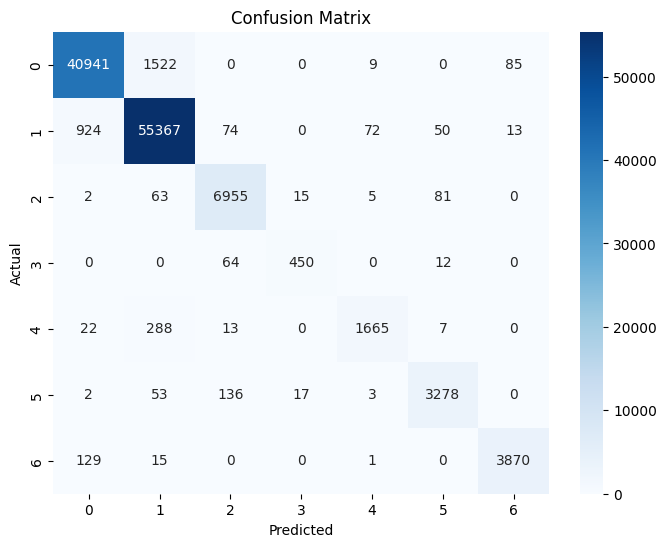

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
from sklearn.metrics import classification_report

print('Classification Report:',classification_report(y_test,pred))

Classification Report:               precision    recall  f1-score   support

           1       0.97      0.96      0.97     42557
           2       0.97      0.98      0.97     56500
           3       0.96      0.98      0.97      7121
           4       0.93      0.86      0.89       526
           5       0.95      0.83      0.89      1995
           6       0.96      0.94      0.95      3489
           7       0.98      0.96      0.97      4015

    accuracy                           0.97    116203
   macro avg       0.96      0.93      0.94    116203
weighted avg       0.97      0.97      0.97    116203



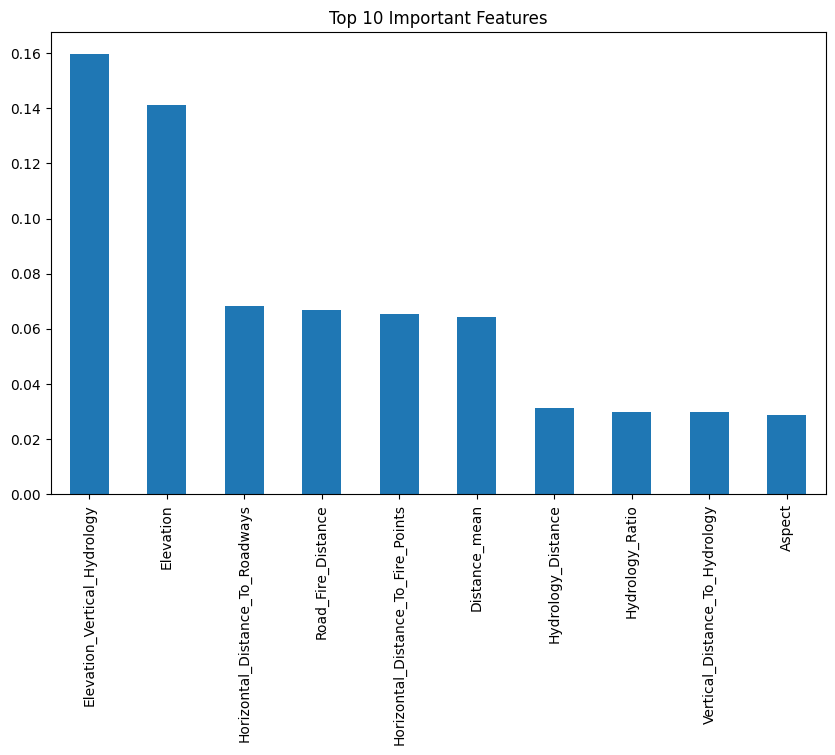

In [38]:
importance=pd.Series(
    rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

# Final Summary

This project demonstrated a complete machine learning workflow for predicting forest cover type using cartographic variables.

Model development process:

Baseline Random Forest  
Accuracy: **95.5%**

Feature Engineering  
Accuracy: **96.1%**

ExtraTrees Model  
Accuracy: **96.0%**

Advanced Feature Engineering  
Accuracy: **96.75%**

The final model achieved **96.75% classification accuracy**, showing that ensemble tree models combined with effective feature engineering perform very well on structured environmental datasets.

Key insights:

• Elevation is the most important factor influencing forest cover type.  
• Distance to roads and fire points significantly affects vegetation distribution.  
• Feature engineering substantially improves model performance.

This notebook demonstrates how machine learning can be used to analyze environmental and geographical datasets effectively.